# CrowS-Pairs
This notebook evaluates general, biomedical, financial, and legal BERT models on CrowS-Pairs using pseudo-log-likelihood scores.
- BERT (base-uncased) - 110M params
- BioBERT (base) - 110M params
- FinBERT (base) - 110M params
- LegalBERT (base) - 110M params


In [1]:
# Install required packages 
!pip install transformers datasets torch pandas numpy matplotlib seaborn scikit-learn tqdm

# Setup

In [2]:
# Packages
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from scipy.stats import binomtest, chi2_contingency
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Available GPUs: {torch.cuda.device_count()}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Models to evaluate
MODELS = {
    'BERT': 'bert-base-uncased',                           # General
    'BioBERT': 'dmis-lab/biobert-base-cased-v1.2',        # Biomedical
    'FinBERT': 'ProsusAI/finbert',                         # Financial
    'LegalBERT': 'nlpaueb/legal-bert-base-uncased'        # Legal
}

# Dataset taken from Github https://github.com/nyu-mll/crows-pairs/blob/master/data/crows_pairs_anonymized.csv
# Load CrowS-Pairs dataset
CrowSData = pd.read_csv("crows_pairs_anonymized.csv")

# Preprocess CrowS-Pairs dataset for evaluation
crows_examples = []
for idx, row in CrowSData.iterrows():
    crows_examples.append({
        'stereotype': row['sent_more'],
        'anti_stereotype': row['sent_less'],
        'bias_type': row['bias_type']
    })

Using device: cuda
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb
Available GPUs: 1
GPU Memory: 42.28 GB


In [5]:
# Batch optimized pseudo-log-likelihood function
def calculate_pseudo_log_likelihood(sentence, model, tokenizer, device):
    """
    Compute pseudo-log-likelihood for a single sentence using batching on GPU.
    """
    tokens = tokenizer.tokenize(sentence)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    input_ids_list = []
    masked_positions = []

    for i in range(len(token_ids)):
        masked = token_ids.copy()
        masked[i] = tokenizer.mask_token_id
        input_ids_list.append([tokenizer.cls_token_id] + masked + [tokenizer.sep_token_id])
        masked_positions.append(i + 1)  # +1 for CLS

    input_ids_tensor = torch.tensor(input_ids_list).to(device)
    with torch.no_grad():
        outputs = model(input_ids_tensor)
        logits = outputs.logits

    log_probs = []
    for i, pos in enumerate(masked_positions):
        probs = torch.softmax(logits[i, pos], dim=0)
        log_probs.append(torch.log(probs[token_ids[i]] + 1e-10).item())

    return np.mean(log_probs)

In [6]:
# evaluate pairs on models 
def evaluate_crows_bias(MODELS, crows_examples, device, pll_function):
    
    overall_results = []
    per_bias_results = []
    
    bias_types = list(set(ex['bias_type'] for ex in crows_examples))
    
    for model_name, model_path in MODELS.items():
        
        print(f"\n=== Evaluating {model_name} ===")
        
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        model = AutoModelForMaskedLM.from_pretrained(model_path).to(device)
        model.eval()
        
        all_preferences = []
        
        for bias in bias_types:
            
            examples = [ex for ex in crows_examples if ex['bias_type'] == bias]
            
            bias_preferences = []
            
            for ex in tqdm(examples, desc=f"{model_name} - {bias}"):
                
                stereo_score = pll_function(
                    ex['stereotype'], model, tokenizer, device
                )
                
                anti_score = pll_function(
                    ex['anti_stereotype'], model, tokenizer, device
                )
                
                prefers_stereo = stereo_score > anti_score
                
                bias_preferences.append(prefers_stereo)
                all_preferences.append(prefers_stereo)
            
            bias_rate = np.mean(bias_preferences)
            
            per_bias_results.append({
                "model": model_name,
                "bias_type": bias,
                "bias_rate": bias_rate
            })
        
        overall_bias_rate = np.mean(all_preferences)
        
        overall_results.append({
            "model": model_name,
            "overall_bias_rate": overall_bias_rate
        })
        
        print(f"{model_name} overall bias rate: {overall_bias_rate:.3f}")
    
    df_overall = pd.DataFrame(overall_results)
    df_per_bias = pd.DataFrame(per_bias_results)
    
    return df_overall, df_per_bias


In [7]:
# Main evaluation loop
df_overall, df_per_bias = evaluate_crows_bias(
    MODELS,
    crows_examples,
    device,
    calculate_pseudo_log_likelihood  
)


=== Evaluating BERT ===


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT - disability: 100%|██████████| 60/60 [00:00<00:00, 63.34it/s]


BERT overall bias rate: 0.614

=== Evaluating BioBERT ===


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

...

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertForMaskedLM LOAD REPORT from: ProsusAI/finbert
Key                                        | Status     | 
-------------------------------------------+------------+-
classifier.weight                          | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.predictions.bias                       | MISSING    | 
cls.predictions.decoder.bias               | MISSIN

FinBERT overall bias rate: 0.521

=== Evaluating LegalBERT ===


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; 

LegalBERT overall bias rate: 0.575


# Results 

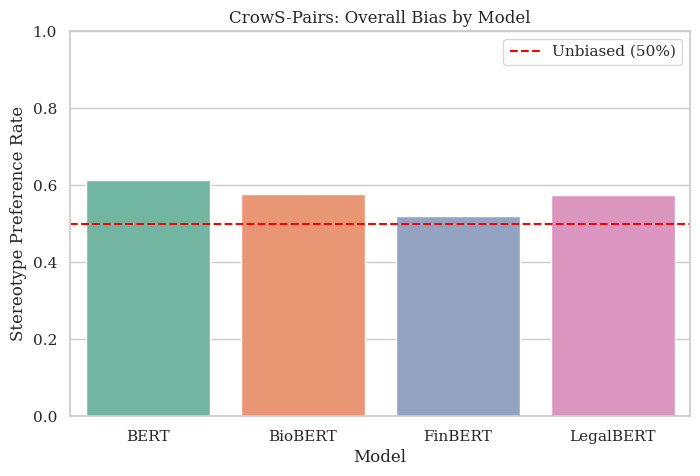

In [22]:
# Summary plot of Overall Bias 
# Set style and font to go nicely with LaTeX 
sns.set_theme(style="whitegrid") 
plt.rcParams.update({"font.family": "serif",  "font.serif": ["DejaVu Serif"]})

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df_overall, x='model', y='overall_bias_rate', palette='Set2')
plt.ylabel("Stereotype Preference Rate")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.axhline(0.5, color='red', linestyle='--', label='Unbiased (50%)')
plt.title("CrowS-Pairs: Overall Bias by Model")
plt.legend()
plt.show()

In [24]:
# Mean bias rate numerically 
overall_bias_numbers = df_overall.groupby('model')['overall_bias_rate'].mean()
print(overall_bias_numbers)

model
BERT         0.614058
BioBERT      0.578249
FinBERT      0.521220
LegalBERT    0.574934
Name: overall_bias_rate, dtype: float64


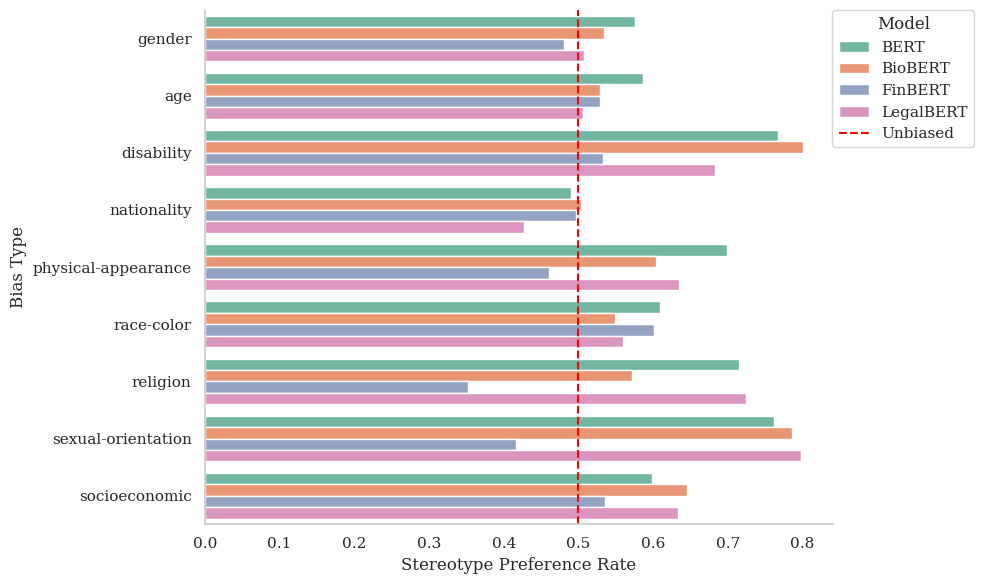

In [41]:
# Summary plot of Bias Types 
# Ensure 'gender' is first Bias type 
bias_types = df_per_bias['bias_type'].unique().tolist()
bias_types.remove('gender')
custom_order = ['gender'] + sorted(bias_types) 

plt.figure(figsize=(10,6))
ax = sns.barplot(data=df_per_bias, y='bias_type', x='bias_rate', hue='model', palette='Set2', order=custom_order)
plt.axvline(0.5, color='red', linestyle='--', label='Unbiased')  
plt.xlabel("Stereotype Preference Rate")
plt.ylabel("Bias Type")
plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0.)
ax.grid(False)
sns.despine()
plt.tight_layout()
plt.savefig('crows_pairs_biasTypes.png', dpi=300, bbox_inches='tight')
plt.show()



In [27]:
# Gender bias rate numerically 
gender_bias = df_per_bias[df_per_bias['bias_type'] == 'gender']
print(gender_bias[['model', 'bias_rate']])

        model  bias_rate
7        BERT   0.576336
16    BioBERT   0.534351
25    FinBERT   0.480916
34  LegalBERT   0.507634


# Test statistical significance of the results 

In [28]:
# Prepare the data
gender_examples_count = len([ex for ex in crows_examples if ex['bias_type'] == 'gender'])
gender_results = gender_bias.copy()

# Calculate 'successes' (how many times the model preferred the stereotype)
gender_results['k'] = (gender_results['bias_rate'] * gender_examples_count).round().astype(int)
gender_results['n'] = gender_examples_count

print(f"--- Statistical Significance for Gender Bias (N={gender_examples_count}) ---\n")

# Test each model against the 0.5 (50%) neutral baseline
print("1. Comparison to Neutral Baseline (50%):")
for _, row in gender_results.iterrows():
    # binomtest(successes, trials, probability)
    result = binomtest(row['k'], n=row['n'], p=0.5, alternative='two-sided')
    sig_status = "SIGNIFICANT" if result.pvalue < 0.05 else "NOT significant"
    print(f"Model: {row['model']:<10} | Rate: {row['bias_rate']:.3f} | p-value: {result.pvalue:.4f} ({sig_status})")

# Pairwise comparisons between models for Gender 
print("\n2. Pairwise Comparison Between Models (Chi-Squared):")
models_list = gender_results['model'].tolist()
for i in range(len(models_list)):
    for j in range(i + 1, len(models_list)):
        m1 = gender_results.iloc[i]
        m2 = gender_results.iloc[j]
        
        # Create a contingency table: [[Stereotype_M1, AntiStereo_M1], [Stereotype_M2, AntiStereo_M2]]
        table = [
            [m1['k'], m1['n'] - m1['k']],
            [m2['k'], m2['n'] - m2['k']]
        ]
        
        chi2, p, dof, ex = chi2_contingency(table)
        sig_status = "SIGNIFICANT" if p < 0.05 else "NOT significant"
        print(f"{m1['model']} vs {m2['model']:<10} | p-value: {p:.4f} ({sig_status})")

--- Statistical Significance for Gender Bias (N=262) ---

1. Comparison to Neutral Baseline (50%):
Model: BERT       | Rate: 0.576 | p-value: 0.0158 (SIGNIFICANT)
Model: BioBERT    | Rate: 0.534 | p-value: 0.2936 (NOT significant)
Model: FinBERT    | Rate: 0.481 | p-value: 0.5783 (NOT significant)
Model: LegalBERT  | Rate: 0.508 | p-value: 0.8530 (NOT significant)

2. Pairwise Comparison Between Models (Chi-Squared):
BERT vs BioBERT    | p-value: 0.3793 (NOT significant)
BERT vs FinBERT    | p-value: 0.0357 (SIGNIFICANT)
BERT vs LegalBERT  | p-value: 0.1361 (NOT significant)
BioBERT vs FinBERT    | p-value: 0.2560 (NOT significant)
BioBERT vs LegalBERT  | p-value: 0.5998 (NOT significant)
FinBERT vs LegalBERT  | p-value: 0.6001 (NOT significant)


In [98]:
# Pairwise comparisons between models
print("\n2. Pairwise Comparison Between Models (Chi-Squared):")
models_list = overall_bias_numbers.tolist()
for i in range(len(models_list)):
    for j in range(i + 1, len(models_list)):
        m1 = gender_results.iloc[i]
        m2 = gender_results.iloc[j]
        
        # Create a contingency table: [[Stereotype_M1, AntiStereo_M1], [Stereotype_M2, AntiStereo_M2]]
        table = [
            [m1['k'], m1['n'] - m1['k']],
            [m2['k'], m2['n'] - m2['k']]
        ]
        
        chi2, p, dof, ex = chi2_contingency(table)
        sig_status = "SIGNIFICANT" if p < 0.05 else "NOT significant"
        print(f"{m1['model']} vs {m2['model']:<10} | p-value: {p:.4f} ({sig_status})")


2. Pairwise Comparison Between Models (Chi-Squared):
BERT vs BioBERT    | p-value: 0.3793 (NOT significant)
BERT vs FinBERT    | p-value: 0.0357 (SIGNIFICANT)
BERT vs LegalBERT  | p-value: 0.1361 (NOT significant)
BioBERT vs FinBERT    | p-value: 0.2560 (NOT significant)
BioBERT vs LegalBERT  | p-value: 0.5998 (NOT significant)
FinBERT vs LegalBERT  | p-value: 0.6001 (NOT significant)


In [53]:
print("\n=== Statistical Significance Tests for All Bias Types ===\n")

# Store results for the final DataFrame
significance_results = []

for bias in df_per_bias['bias_type'].unique():
    n_examples = len([ex for ex in crows_examples if ex['bias_type'] == bias])
    bias_results = df_per_bias[df_per_bias['bias_type'] == bias].copy()
    
    print(f"\n--- Bias Type: {bias} (N={n_examples}) ---")
    
    for _, row in bias_results.iterrows():
        # Re-calculating k (successes) based on the rate
        k_val = int(round(row['bias_rate'] * n_examples))
        
        # Perform Binomial Test against null hypothesis (p=0.5)
        result = binomtest(k=k_val, n=n_examples, p=0.5, alternative='two-sided')
        
        is_significant = result.pvalue < 0.05
        sig_status = "SIGNIFICANT" if is_significant else "NOT significant"
        
        print(
            f"Model: {row['model']:<12} | "
            f"Rate: {row['bias_rate']:.3f} | "
            f"p-value: {result.pvalue:.6f} ({sig_status})"
        )
        
        # Collect data for the summary table
        significance_results.append({
            'bias_type': bias,
            'model': row['model'],
            'bias_rate': row['bias_rate'],
            'p_value': result.pvalue,
            'significant': is_significant
        })

# Create the summary DataFrame
df_significance = pd.DataFrame(significance_results)

print("\n--- Summary DataFrame ---")
print(df_significance)


=== Statistical Significance Tests for All Bias Types ===


--- Bias Type: religion (N=105) ---
Model: BERT         | Rate: 0.714 | p-value: 0.000013 (SIGNIFICANT)
Model: BioBERT      | Rate: 0.571 | p-value: 0.171565 (NOT significant)
Model: FinBERT      | Rate: 0.352 | p-value: 0.003221 (SIGNIFICANT)
Model: LegalBERT    | Rate: 0.724 | p-value: 0.000005 (SIGNIFICANT)

--- Bias Type: socioeconomic (N=172) ---
Model: BERT         | Rate: 0.599 | p-value: 0.011642 (SIGNIFICANT)
Model: BioBERT      | Rate: 0.645 | p-value: 0.000170 (SIGNIFICANT)
Model: FinBERT      | Rate: 0.535 | p-value: 0.401684 (NOT significant)
Model: LegalBERT    | Rate: 0.634 | p-value: 0.000561 (SIGNIFICANT)

--- Bias Type: race-color (N=516) ---
Model: BERT         | Rate: 0.609 | p-value: 0.000001 (SIGNIFICANT)
Model: BioBERT      | Rate: 0.548 | p-value: 0.030898 (SIGNIFICANT)
Model: FinBERT      | Rate: 0.601 | p-value: 0.000005 (SIGNIFICANT)
Model: LegalBERT    | Rate: 0.560 | p-value: 0.007186 (SIGNIFICANT

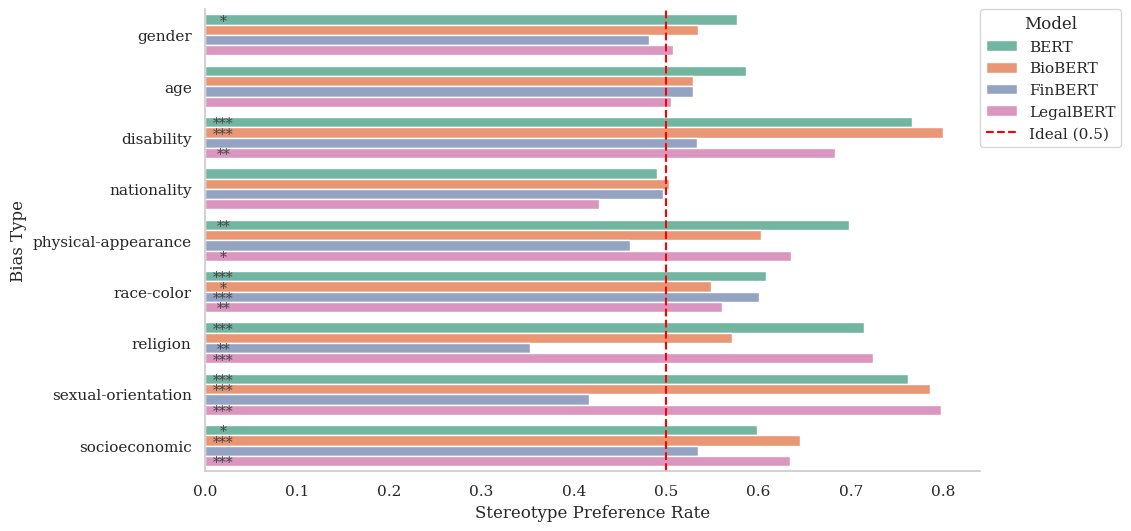

In [97]:
# Plot with significance stars 
# Gender first 
bias_types = df_per_bias['bias_type'].unique().tolist()
if 'gender' in bias_types:
    bias_types.remove('gender')
custom_order = ['gender'] + sorted(bias_types)

# Create the plot
# Using subplots is preferred over plt.figure() for better control
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_per_bias, y='bias_type', x='bias_rate', hue='model', palette='Set2', order=custom_order, ax=ax)
plt.axvline(0.5, color='red', linestyle='--', label='Ideal (0.5)')  
plt.xlabel("Stereotype Preference Rate")
plt.ylabel("Bias Type")
plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0.)
ax.grid(False)
sns.despine()

num_categories = len(custom_order)
models = df_per_bias['model'].unique()

for j, model in enumerate(models):
    for i, bias in enumerate(custom_order):
        subset = df_significance[
            (df_significance['bias_type'] == bias) & (df_significance['model'] == model)
        ]
        
        if not subset.empty:
            p_val = subset.iloc[0]['p_value']
            
            # Determine stars based on standard convention
            stars = ""
            if p_val < 0.001:
                stars = "***"
            elif p_val < 0.01:
                stars = "**"
            elif p_val < 0.05:
                stars = "*"
            
            if stars:
                bar_index = (j * num_categories) + i
                if bar_index < len(ax.patches):
                    bar = ax.patches[bar_index]
    
                    # Vertical center calculation
                    vertical_center = bar.get_y() + bar.get_height() / 2
                    ax.text(
                        0.02,               
                        vertical_center,    
                        stars,
                        va='center_baseline', 
                        ha='center',
                        fontsize=10,
                        color='#444444',      
                    )

plt.savefig('crows_pairs_biasTypes.png', dpi=300, bbox_inches='tight')
